### Eficiencia por PIB
​**A Pergunta:** O dinheiro "compra" mais medalhas em qual dos dois eventos?

​A Comparação: Cruzar o PIB dos países com o quadro de medalhas de ambos os eventos.

​Hipótese: Equipamentos paralímpicos (cadeiras de rodas de titânio, próteses de fibra de carbono) são caríssimos. A correlação entre PIB e vitória é mais forte nas Paralimpíadas do que nas Olimpíadas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans

In [96]:
df_pib = pd.read_csv('pib_mundial_2024_worldometers.csv', encoding='utf-8')
display(df_pib.head())

df_olimpiadas = pd.read_csv('medalhas_olimpiadas_wikipedia.csv', encoding='utf-8')
display(df_olimpiadas.head())

df_paraolimpiadas = pd.read_csv('medalhas_paralimpiadas_wikipedia.csv', encoding='utf-8')
display(df_paraolimpiadas.head())

,#,País,PIB,PIB (Valor Total),Crescimento do PIB,PIB per Capita
0,1,Estados Unidos,"$29,3 trilhões",$29.298.025.000.000,"2,8%",$86.145
1,2,China,"$18,75 trilhões",$18.749.759.000.000,5%,$13.314
2,3,Alemanha,"$4,68 trilhões",$4.684.182.000.000,"−0,5%",$56.087
3,4,Japão,"$4,02 trilhões",$4.019.382.000.000,"0,1%",$32.443
4,5,Índia,"$3,91 trilhões",$3.909.892.000.000,"6,5%",$2.695


,No.,País,Jogos,Ouro,Prata,Bronze,Total
0,1,USA Estados Unidos,29,1101,880,781,2762
1,2,URS União Soviética,9,395,319,296,1010
2,3,CHN China,12,302,227,197,726
3,4,GBR Grã-Bretanha,30,300,338,344,982
4,5,FRA França,30,240,280,298,818


,País,№,Ouro,Prata,Bronze,Total
0,África do Sul (RSA),11,121,95,88,304
1,Alemanha (GER) [a],8,199,266,253,718
2,Alemanha Ocidental (FRG) [b],8,322,260,246,828
3,Alemanha Oriental (GDR) [c],1,0,3,1,4
4,Angola (ANG),6,4,3,1,8


In [97]:
df_pib.info()
display(list(df_pib.columns)) 
df_olimpiadas.info()
display(list(df_olimpiadas.columns))  
df_paraolimpiadas.info()
display(list(df_paraolimpiadas.columns))


<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   #                   218 non-null    int64
 1   País                218 non-null    str  
 2   PIB                 218 non-null    str  
 3   PIB (Valor Total)   218 non-null    str  
 4   Crescimento do PIB  218 non-null    str  
 5   PIB per Capita      218 non-null    str  
dtypes: int64(1), str(5)
memory usage: 10.3 KB


['#',
 'País',
 'PIB',
 'PIB (Valor Total)',
 'Crescimento do PIB',
 'PIB per Capita']

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   No.     155 non-null    int64
 1   País    155 non-null    str  
 2   Jogos   155 non-null    int64
 3   Ouro    155 non-null    int64
 4   Prata   155 non-null    int64
 5   Bronze  155 non-null    int64
 6   Total   155 non-null    int64
dtypes: int64(6), str(1)
memory usage: 8.6 KB


['No.', 'País', 'Jogos', 'Ouro', 'Prata', 'Bronze', 'Total']

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   País    132 non-null    str  
 1   №       132 non-null    int64
 2   Ouro    132 non-null    int64
 3   Prata   132 non-null    int64
 4   Bronze  132 non-null    int64
 5   Total   132 non-null    int64
dtypes: int64(5), str(1)
memory usage: 6.3 KB


['País', '№', 'Ouro', 'Prata', 'Bronze', 'Total']

##### Tratamento do nome dos países para ficarem iguais em todos os datasets

*Olimpiadas*
Trata o texto do nome das olimpiadas pois estava diferente do que tem no pib, estava: USA Estados Unidos, após o tratamento fica uma coluna para o país que tem só o nome: Estados Unidos e outra coluna para a NOC que recebe a sigla (talvez use no futuro para comparar com a tabela de atletas em outras analises).

In [ ]:
df_para_limpo = df_olimpiadas['País'].str.extract(r'^([A-Z]{3})\s+(.*)')

df_para_limpo.columns = ['NOC', 'País_Limpo']

df_olimpiadas['NOC'] = df_para_limpo['NOC']
df_olimpiadas['País'] = df_para_limpo['País_Limpo']

df_olimpiadas['País'] = df_olimpiadas['País'].str.replace(r'\[.*\]|\*', '', regex=True).str.strip()

display(df_olimpiadas.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
2,3,China,12,302,227,197,726,CHN
3,4,Grã-Bretanha,30,300,338,344,982,GBR
4,5,França,30,240,280,298,818,FRA


*Trata para as paralimpiadas*
trata o nome do país para ficar igual aos do pib, estava com o nome do país e o código entre parênteses, agora só tem o nome do paíse o codigo do país em uma coluna separada, isso facilita a comparação entre os dataframes

In [ ]:
df_paraolimpiadas['NOC'] = df_paraolimpiadas['País'].str.extract(r'\((.*?)\)')

df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\s*\(.*', '', regex=True)
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\[.*\]', '', regex=True).str.strip()

display(df_paraolimpiadas.head())

,País,№,Ouro,Prata,Bronze,Total,NOC
0,África do Sul,11,121,95,88,304,RSA
1,Alemanha,8,199,266,253,718,GER
2,Alemanha Ocidental,8,322,260,246,828,FRG
3,Alemanha Oriental,1,0,3,1,4,GDR
4,Angola,6,4,3,1,8,ANG


Junta as Tres alemanhas paralimpicas em uma só, soma as medalhas e usa o código GER.

In [ ]:
alemanhas = ['Alemanha Ocidental', 'Alemanha Oriental']
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].replace(alemanhas, 'Alemanha')

df_para_final = df_paraolimpiadas.groupby('País').agg({
    'Total': 'sum',
    'NOC': 'first' 
}).reset_index()
display(df_para_final.head())

,País,Total,NOC
0,Alemanha,1550,GER
1,Angola,8,ANG
2,Argentina,165,ARG
3,Argélia,85,ALG
4,Arábia Saudita,5,KSA


Exclui a linha que tinhas a soma de todas as medalhas

In [22]:
df_paraolimpiadas = df_paraolimpiadas[df_paraolimpiadas['País'] != 'Totais']

Cria o total de medalhas olimpicas e paralimpicas

In [23]:
df_olimpico_total = df_olimpiadas.groupby('País')['Total'].sum().reset_index()
df_olimpico_total = df_olimpico_total.sort_values(by='Total', ascending=False)
df_olimpico_total.columns = ['País', 'Total_Olimpico']

df_paralimpico_total = df_paraolimpiadas.groupby('País')['Total'].sum().reset_index()
df_paralimpico_total = df_paralimpico_total.sort_values(by='Total', ascending=False)
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

In [24]:
display(df_olimpico_total.head())
display(df_paralimpico_total.head())

,País,Total_Olimpico
53,Estados Unidos,2762
143,União Soviética,1010
65,Grã-Bretanha,982
60,França,818
31,China,726


,País,Total_Paralimpico
40,Estados Unidos,2283
48,Grã-Bretanha,1914
0,Alemanha,1550
22,China,1237
6,Austrália,1205


In [25]:
df_olimpico_total.columns = ['País', 'Total_Olimpico']
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

df_olim_e_para = pd.merge(df_olimpico_total, df_paralimpico_total, on='País', how='outer')

df_analise_socioeconomica = pd.merge(df_olim_e_para, df_pib, on='País').sort_values(by='Total_Olimpico', ascending=False)
df_analise_socioeconomica.fillna(0, inplace=True)
display(df_analise_socioeconomica.head())

,País,Total_Olimpico,Total_Paralimpico,#,PIB,PIB (Valor Total),Crescimento do PIB,PIB per Capita
44,Estados Unidos,2762.0,2283.0,1,"$29,3 trilhões",$29.298.025.000.000,"2,8%",$86.145
50,França,818.0,1092.0,7,"$3,16 trilhões",$3.160.902.000.000,"1,1%",$46.187
25,China,726.0,1237.0,2,"$18,75 trilhões",$18.749.759.000.000,5%,$13.314
1,Alemanha,685.0,1550.0,3,"$4,68 trilhões",$4.684.182.000.000,"−0,5%",$56.087
69,Itália,657.0,665.0,8,"$2,37 trilhões",$2.372.059.000.000,"0,7%",$40.224


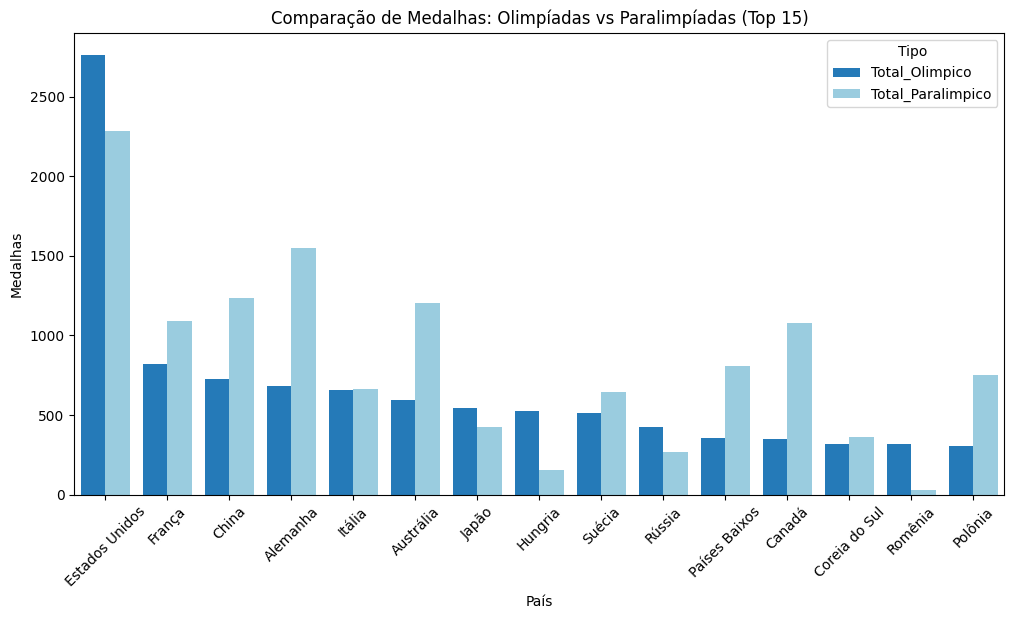

In [44]:
df_top = df_analise_socioeconomica.nlargest(15, 'Total_Olimpico')

df_plot = df_top.melt(id_vars='País', value_vars=['Total_Olimpico', 'Total_Paralimpico'], 
                      var_name='Tipo', value_name='Medalhas')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo',  palette=["#0c7ed0", "#8ED1EB"])
plt.xticks(rotation=45)
plt.title('Comparação de Medalhas: Olimpíadas vs Paralimpíadas (Top 15)')
plt.show()

#### Agora vamos analizar o total de medalha a cada 1 bilhao do pib

**Primeiro para as paralimpiadas**

Arrumar a coluna: 'PIB (Valor Total)' que tinha formato string pois tinha um '$' antes do valor do PIB, vamos transforma-la em um valor real usando o to_numeric do pandas

In [28]:
df_analise_socioeconomica['PIB_Numerico'] = df_analise_socioeconomica['PIB (Valor Total)'].str.replace(r'[\$\.]', '', regex=True)

df_analise_socioeconomica['PIB_Numerico'] = pd.to_numeric(df_analise_socioeconomica['PIB_Numerico'])

Cria uma coluna chamada 'eficiencia_para' para a analise, esse coluna recebe o total de medalhas paralimpicas do df_analise_socioeconomica e divide pelo pib numerico que é o que pib que tratamos ateriormente dividido por 1e12 para transformar o valor em trilhões

In [29]:
df_analise_socioeconomica['Eficiencia_Para'] = df_analise_socioeconomica['Total_Paralimpico'] / (df_analise_socioeconomica['PIB_Numerico'] / 1e12) 

Aqui criamos o grafico que realiza o comparativo entre a eficiência dos países em relação ao PIB e as medalhas paralimpicas.

C:\Users\maria\AppData\Local\Temp\ipykernel_6880\1731486147.py:6: UserWarning: 
The palette list has fewer values (2) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


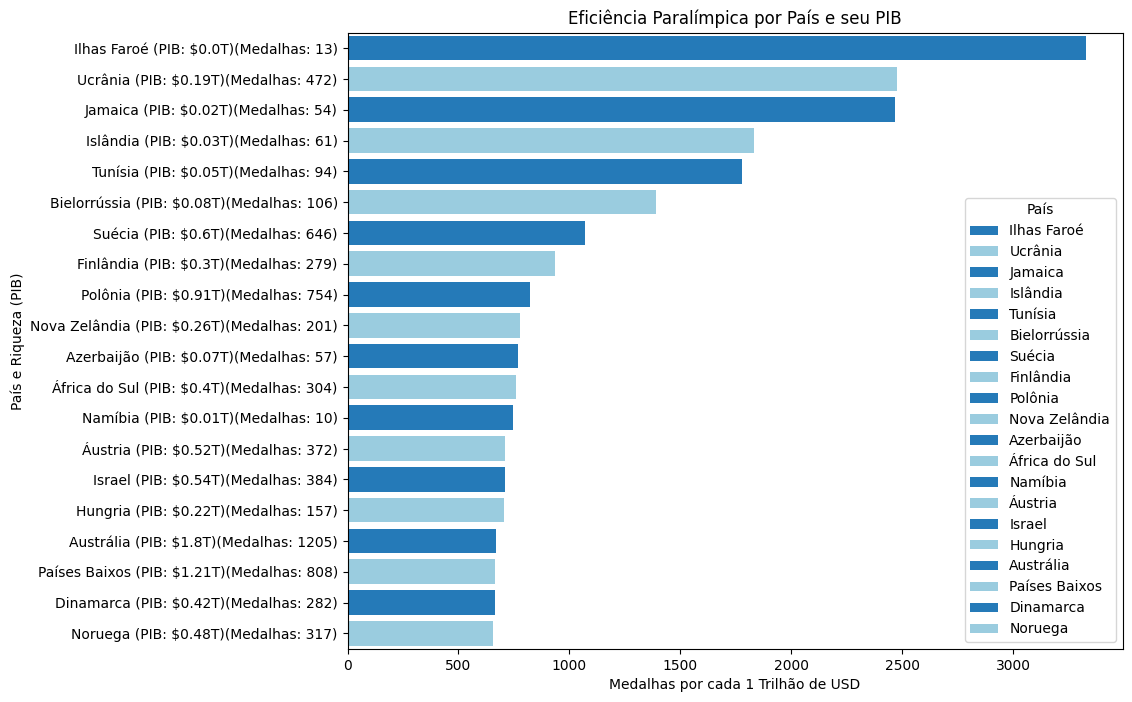

In [75]:
df_ranking = df_analise_socioeconomica.nlargest(20, 'Eficiencia_Para')
df_ranking['Pais_com_PIB'] = df_ranking['País'] + " (PIB: $" + (df_ranking['PIB_Numerico'] / 1e12).round(2).astype(str) + "T)" + "(Medalhas: " + df_ranking['Total_Paralimpico'].astype(int).astype(str) + ")"

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_ranking, 
    x='Eficiencia_Para', 
    y='Pais_com_PIB',
    hue='País', 
    palette=['#0c7ed0', '#8ED1EB']
)

plt.title('Eficiência Paralímpica por País e seu PIB')
plt.xlabel('Medalhas por cada 1 Trilhão de USD')
plt.ylabel('País e Riqueza (PIB)')
plt.show()

**Agora analisar as olimpiadas**

In [32]:
df_analise_socioeconomica['Eficiencia_Olimp'] = df_analise_socioeconomica['Total_Olimpico'] / (df_analise_socioeconomica['PIB_Numerico'] / 1e12) 

C:\Users\maria\AppData\Local\Temp\ipykernel_6880\1407806745.py:6: UserWarning: 
The palette list has fewer values (2) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


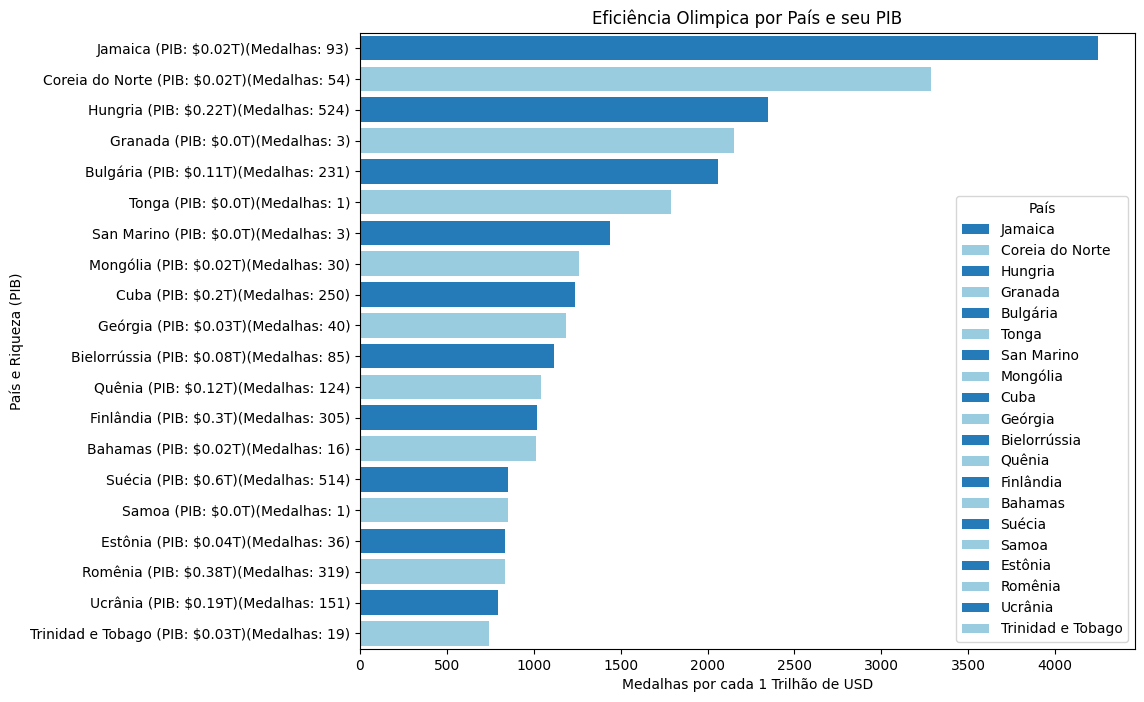

In [82]:


df_ranking = df_analise_socioeconomica.nlargest(20, 'Eficiencia_Olimp')
df_ranking['Pais_com_PIB'] = df_ranking['País'] + " (PIB: $" + (df_ranking['PIB_Numerico'] / 1e12).round(2).astype(str) + "T)" + "(Medalhas: " + df_ranking['Total_Olimpico'].astype(int).astype(str) + ")"

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_ranking, 
    x='Eficiencia_Olimp', 
    y='Pais_com_PIB',
    hue='País', 
    palette=['#0c7ed0', '#8ED1EB']
)

plt.title('Eficiência Olimpica por País e seu PIB')
plt.xlabel('Medalhas por cada 1 Trilhão de USD')
plt.ylabel('País e Riqueza (PIB)')
plt.show()

<Figure size 1200x800 with 0 Axes>

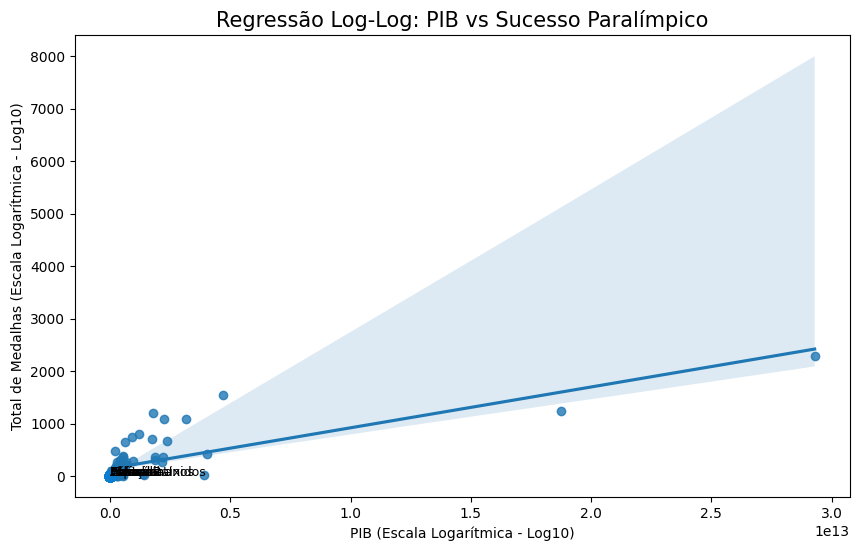

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparar os dados para o algoritmo (K-Means precisa de escala padronizada)
# Usamos log para que os EUA não "puxem" o grupo sozinho
X = df_analise_socioeconomica[['PIB_Numerico', 'Total_Paralimpico']].copy()
X['PIB_Numerico'] = np.log10(X['PIB_Numerico'])
X['Total_Paralimpico'] = np.log10(X['Total_Paralimpico'] + 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Criar 4 Grupos (Clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_analise_socioeconomica['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Plotar o resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_analise_socioeconomica, 
    x='PIB_Numerico', 
    y='Total_Paralimpico', 
    hue='Cluster', 
    palette='viridis', 
    s=100, 
    alpha=0.7
)

plt.xscale('log')
plt.title('Agrupamento de Países: Riqueza vs. Sucesso Paralímpico', fontsize=15)
plt.show()